<a href="https://colab.research.google.com/github/krackofficer/EDA-Assignment-in-Machine-Learning-/blob/main/Copy_of_EDA1_Bike_Details_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Upload CSV manually
from google.colab import files
uploaded = files.upload()

Saving BIKE DETAILS.csv to BIKE DETAILS.csv


In [4]:
import pandas as pd
df = pd.read_csv("BIKE DETAILS.csv")
df.head()  # Optional: check data

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime

df = pd.read_csv('BIKE DETAILS.csv')

### 1.What is the range of selling prices in the dataset?

In [6]:
range_price = df['selling_price'].max() - df['selling_price'].min()
print(f"Range of selling prices: {range_price}")

Range of selling prices: 755000


### 2.What is the median selling price for bikes in the dataset?

In [7]:
median_price = df['selling_price'].median()
print(f"Median selling price: {median_price}")

Median selling price: 45000.0


### 3.What is the most common seller type?

In [8]:
most_common_seller = df['seller_type'].mode()[0]
print(f"Most common seller type: {most_common_seller}")

Most common seller type: Individual


### 4.How many bikes have driven more than 50,000 kilometers?

In [9]:
high_km_bikes = df[df['km_driven'] > 50000].shape[0]
print(f"Bikes with more than 50,000 km: {high_km_bikes}")

Bikes with more than 50,000 km: 170


### 5.What is the average km_driven value for each ownership type?

In [10]:
avg_km_by_owner = df.groupby('owner')['km_driven'].mean()
print(avg_km_by_owner)

owner
1st owner     32816.583333
2nd owner     39288.991870
3rd owner     33292.181818
4th owner    311500.000000
Name: km_driven, dtype: float64


### 6.What proportion of bikes are from the year 2015 or older?

In [11]:
older_bikes = df[df['year'] <= 2015].shape[0] / df.shape[0]
print(f"Proportion of bikes from 2015 or older: {older_bikes:.2%}")

Proportion of bikes from 2015 or older: 56.64%


### 7.What is the trend of missing values across the dataset?

In [12]:
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64


### 8.What is the highest ex_showroom_price recorded, and for which bike?

In [13]:
max_price_index = df['ex_showroom_price'].idxmax()
bike_name = df.loc[max_price_index, 'name']
max_price = df.loc[max_price_index, 'ex_showroom_price']
print(f"Highest ex_showroom_price is {max_price} for bike: {bike_name}")

Highest ex_showroom_price is 1278000.0 for bike: Harley-Davidson Street Bob


### 9.What is the total number of bikes listed by each seller type?

In [14]:
seller_counts = df['seller_type'].value_counts()
print(seller_counts)

seller_type
Individual    1055
Dealer           6
Name: count, dtype: int64


### 10.What is the relationship between selling_price and km_driven for first-owner bikes?

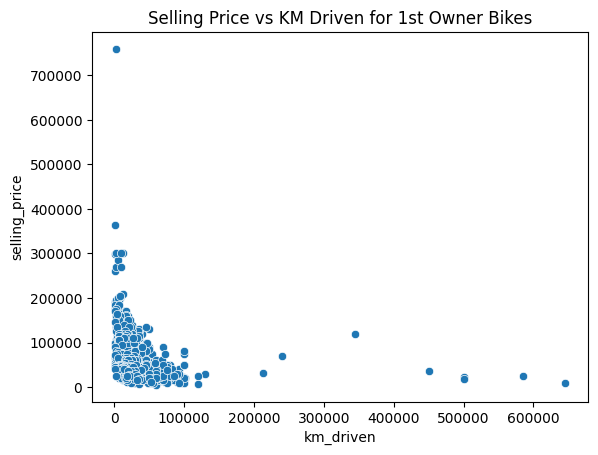

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

first_owner_df = df[df['owner'] == '1st owner']
sns.scatterplot(data=first_owner_df, x='km_driven', y='selling_price')
plt.title('Selling Price vs KM Driven for 1st Owner Bikes')
plt.show()

### 11.Identify and remove outliers in the km_driven column using the IQR method

In [16]:
Q1 = df['km_driven'].quantile(0.25)
Q3 = df['km_driven'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[(df['km_driven'] >= lower_bound) & (df['km_driven'] <= upper_bound)]
print(f"Original rows: {df.shape[0]}, After outlier removal: {df_no_outliers.shape[0]}")

Original rows: 1061, After outlier removal: 1022


### 12.Perform a bivariate analysis to visualize the relationship between year and selling_price

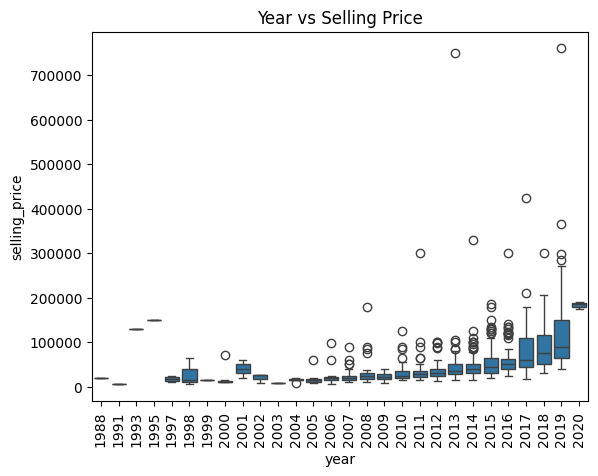

In [17]:
sns.boxplot(data=df, x='year', y='selling_price')
plt.xticks(rotation=90)
plt.title('Year vs Selling Price')
plt.show()

### 13.What is the average depreciation in selling price based on the bike's age (current year - manufacturing year)?

In [18]:
import datetime
current_year = datetime.datetime.now().year
df['age'] = current_year - df['year']
avg_depreciation = df.groupby('age')['selling_price'].mean()
print("Average depreciation by bike age:\n", avg_depreciation)

Average depreciation by bike age:
 age
5     183333.333333
6     119689.511628
7      87660.374046
8      78894.736842
9      58469.018692
10     56500.000000
11     48668.131868
12     51136.986301
13     35748.400000
14     35655.721311
15     31793.333333
16     22267.857143
17     34289.285714
18     24927.586207
19     23380.000000
20     16978.571429
21     15100.000000
22      8000.000000
23     20666.666667
24     40000.000000
25     20833.333333
26     15000.000000
27     28333.333333
28     17500.000000
30    150000.000000
32    130000.000000
34      6000.000000
37     20000.000000
Name: selling_price, dtype: float64


### 14.Which bike names are priced significantly above the average price for their manufacturing year?

In [19]:
avg_price_by_year = df.groupby('year')['selling_price'].mean()
df['year_avg_price'] = df['year'].map(avg_price_by_year)
outliers = df[df['selling_price'] > 1.5 * df['year_avg_price']]
print(outliers[['name', 'year', 'selling_price', 'year_avg_price']])

                                     name  year  selling_price  year_avg_price
2     Royal Enfield Classic Gunmetal Grey  2018         150000    87660.374046
7    Royal Enfield Bullet 350 [2007-2011]  2008         180000    34289.285714
13                          Yamaha YZF R3  2019         365000   119689.511628
18    Royal Enfield Classic Gunmetal Grey  2018         150000    87660.374046
23                          Jawa Standard  2019         180000   119689.511628
..                                    ...   ...            ...             ...
979             Royal Enfield Thunder 500  2015         105000    56500.000000
981             Royal Enfield Thunder 350  2013         105000    51136.986301
983             Royal Enfield Classic 350  2015         100000    56500.000000
984             Royal Enfield Classic 500  2014          95000    48668.131868
985             Royal Enfield Classic 500  2011          90000    35655.721311

[157 rows x 4 columns]


### 15.Develop a correlation matrix for numeric columns and visualize it using a heatmap.

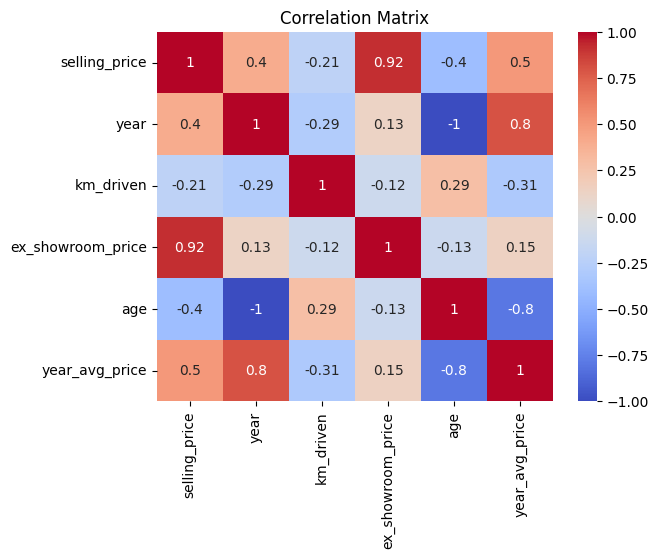

In [20]:
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_cols.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()